In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/features.csv')
model = joblib.load('../data/models/win_prob_model.pkl')

FEATURES = [
    'inning', 'over', 'legal_ball', 'balls_remaining',
    'wickets_remaining', 'runs_so_far', 'current_run_rate',
    'runs_required', 'required_run_rate', 'run_rate_diff',
    'phase', 'toss_advantage'
]

print(f"Data loaded: {df.shape}")
print("Ready!")

Data loaded: (290278, 33)
Ready!


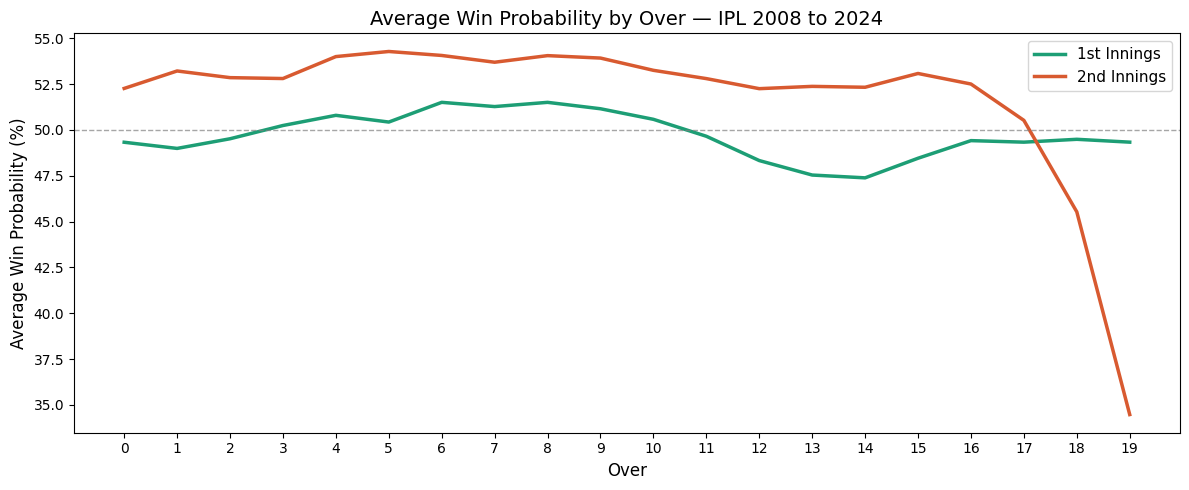

Done!


In [2]:
# Visualization 1 — Average win probability by over for each innings
inn1 = df[df['inning'] == 1].copy()
inn2 = df[df['inning'] == 2].copy()

inn1_preds = model.predict_proba(inn1[FEATURES].fillna(0))[:, 1]
inn2_preds = model.predict_proba(inn2[FEATURES].fillna(0))[:, 1]

inn1['win_prob'] = inn1_preds
inn2['win_prob'] = inn2_preds

inn1_by_over = inn1.groupby('over')['win_prob'].mean()
inn2_by_over = inn2.groupby('over')['win_prob'].mean()

plt.figure(figsize=(12, 5))
plt.plot(inn1_by_over.index, inn1_by_over.values * 100, 
         label='1st Innings', color='#1D9E75', linewidth=2.5)
plt.plot(inn2_by_over.index, inn2_by_over.values * 100, 
         label='2nd Innings', color='#D85A30', linewidth=2.5)
plt.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('Over', fontsize=12)
plt.ylabel('Average Win Probability (%)', fontsize=12)
plt.title('Average Win Probability by Over — IPL 2008 to 2024', fontsize=14)
plt.legend(fontsize=11)
plt.xticks(range(0, 20))
plt.tight_layout()
plt.savefig('../data/models/win_prob_by_over.png', dpi=150)
plt.show()
print("Done!")

In [ ]:
#What the chart shows:

#2nd innings (orange) stays above 50% from overs 0-17 — chasing teams have a slight advantage on average across all IPL history
#The dramatic drop at over 18-19 — if a chasing team hasn't won by over 17, they're in serious trouble. The probability crashes from 52% to 34% in the last 2 overs
#1st innings (green) stays flat around 49-51% — the model is uncertain about 1st innings outcomes because there's no chase pressure yet, which makes sense

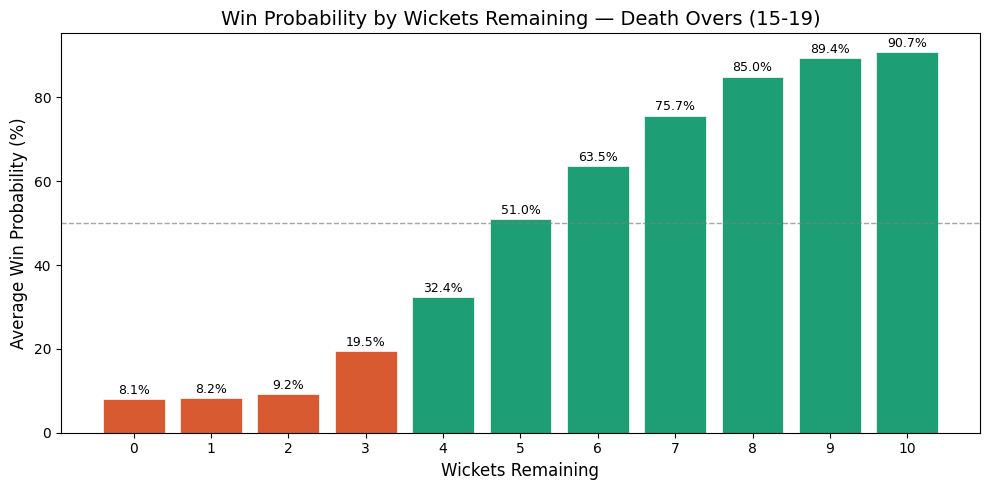

Done!


In [3]:
# Visualization 2 — How wickets remaining affects win probability in death overs
death = df[(df['inning'] == 2) & (df['over'] >= 15)].copy()
death['win_prob'] = model.predict_proba(death[FEATURES].fillna(0))[:, 1]

wicket_impact = death.groupby('wickets_remaining')['win_prob'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(wicket_impact.index, wicket_impact.values,
               color=['#D85A30' if w <= 3 else '#1D9E75' for w in wicket_impact.index],
               edgecolor='white', linewidth=0.5)
plt.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('Wickets Remaining', fontsize=12)
plt.ylabel('Average Win Probability (%)', fontsize=12)
plt.title('Win Probability by Wickets Remaining — Death Overs (15-19)', fontsize=14)
plt.xticks(range(0, 11))
for bar, val in zip(bars, wicket_impact.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/models/wickets_impact.png', dpi=150)
plt.show()
print("Done!")

In [ ]:
#The story:

#0-2 wickets remaining — only 8-9% chance of winning. Basically over.
#3 wickets remaining — 19.5% — still very unlikely
#5 wickets remaining — exactly 51% — the tipping point. 5 wickets is the survival line in death overs
#7+ wickets remaining — 75%+ chance of winning — you're in control

#The big insight: Losing your 5th wicket in death overs is the single most dangerous moment in a T20 chase.
#Above 5 you're favourites, below 5 you're underdogs.

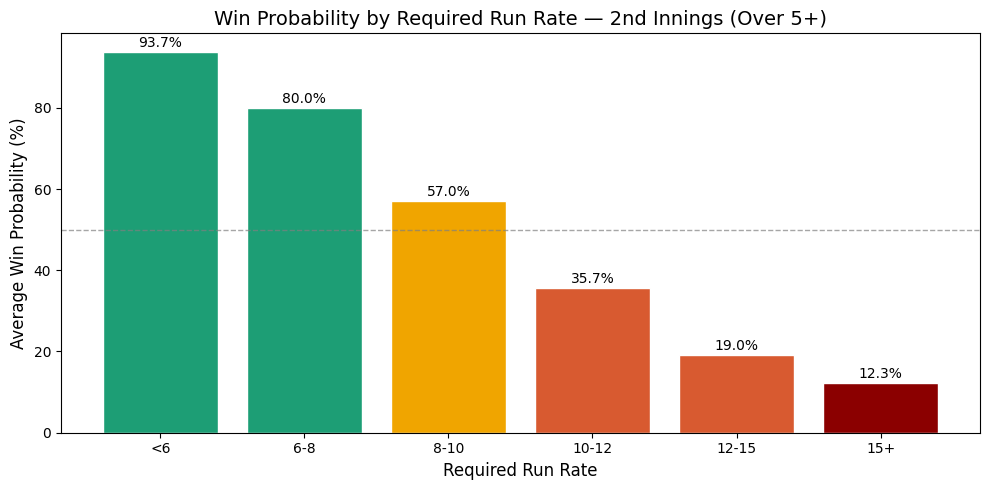

Done!


In [5]:
# Visualization 3 — Required run rate vs win probability in 2nd innings
inn2 = df[(df['inning'] == 2) & (df['over'] >= 5)].copy()
inn2['win_prob'] = model.predict_proba(inn2[FEATURES].fillna(0))[:, 1]

# Bin required run rate
inn2['rrr_bin'] = pd.cut(inn2['required_run_rate'],
                          bins=[0, 6, 8, 10, 12, 15, 100],
                          labels=['<6', '6-8', '8-10', '10-12', '12-15', '15+'])

rrr_impact = inn2.groupby('rrr_bin', observed=True)['win_prob'].mean() * 100

plt.figure(figsize=(10, 5))
colors = ['#1D9E75', '#1D9E75', '#F0A500', '#D85A30', '#D85A30', '#8B0000']
bars = plt.bar(rrr_impact.index, rrr_impact.values,
               color=colors, edgecolor='white')
plt.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('Required Run Rate', fontsize=12)
plt.ylabel('Average Win Probability (%)', fontsize=12)
plt.title('Win Probability by Required Run Rate — 2nd Innings (Over 5+)', fontsize=14)
for bar, val in zip(bars, rrr_impact.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../data/models/rrr_impact.png', dpi=150)
plt.show()
print("Done!")

In [ ]:
#What it shows:

#RRR below 6 — 93.7% win probability. You're cruising, match is basically won
#RRR 6-8 — 80% — comfortable, still in control
#RRR 8-10 — 57% — danger zone begins, still slight favourite
#RRR 10-12 — 35.7% — you're the underdog now
#RRR 12-15 — 19% — very unlikely
#RRR 15+ — 12.3% — almost impossible
#The key insight: 
# A required run rate of 10 is the psychological and statistical breaking point in IPL chases. Below 10 you have a fighting chance, above 10 the odds flip sharply against you.

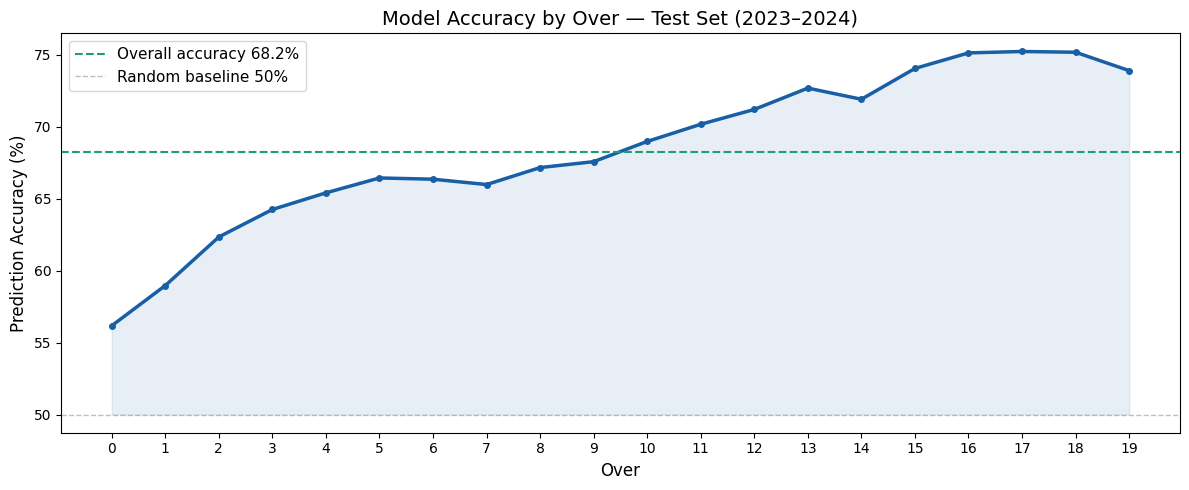

Done!


In [6]:
# Visualization 4 — Model accuracy by over
df['year'] = pd.to_datetime(df['date']).dt.year
test = df[df['year'] >= 2023].copy()
test['win_prob'] = model.predict_proba(test[FEATURES].fillna(0))[:, 1]
test['predicted_winner'] = (test['win_prob'] >= 0.5).astype(int)
test['correct'] = (test['predicted_winner'] == test['batting_team_won']).astype(int)

accuracy_by_over = test.groupby('over')['correct'].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(accuracy_by_over.index, accuracy_by_over.values,
         color='#185FA5', linewidth=2.5, marker='o', markersize=4)
plt.axhline(68.22, color='#1D9E75', linestyle='--',
            linewidth=1.5, label='Overall accuracy 68.2%')
plt.axhline(50, color='gray', linestyle='--',
            linewidth=1, alpha=0.5, label='Random baseline 50%')
plt.fill_between(accuracy_by_over.index, accuracy_by_over.values, 50,
                 alpha=0.1, color='#185FA5')
plt.xlabel('Over', fontsize=12)
plt.ylabel('Prediction Accuracy (%)', fontsize=12)
plt.title('Model Accuracy by Over — Test Set (2023–2024)', fontsize=14)
plt.legend(fontsize=11)
plt.xticks(range(0, 20))
plt.tight_layout()
plt.savefig('../data/models/accuracy_by_over.png', dpi=150)
plt.show()
print("Done!")

In [ ]:
#The story:

#Over 0 — 56% accuracy. Early in the match, the model barely knows more than a coin flip
#Overs 0-9 — accuracy steadily climbs as more match information becomes available
#Over 10 onwards — crosses 68% and keeps rising above the overall average
#Overs 16-18 — peaks at 75% accuracy. By the death overs the model knows almost exactly what's going to happen

#The big insight: 
# The model gets smarter as the match progresses. This is exactly how real cricket works — early overs are unpredictable, death overs tell the whole story.